In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import gymnasium as gym
from tqdm import tqdm
import sys
sys.path.insert(0, "../src/")
from Network import *
from inputFuc import *
from plotting import *
from utilsRL import *
from IPython.display import display, clear_output
import time
import imageio

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)

general_config['save_path'] = "../saved_models/Cartpole/"

#### With P learning ###
dt = general_config["dt"]

# init both teacher and student net
batch = train_config["batch_size"]
general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

env = CartPoleCustomize()

n_actions = env.env.action_space.n.item()
# Get the number of state observations
obs, info = env.reset()
n_observations = obs.shape[-1]

actor_config = dict(default_model_config)
critic_config = dict(default_model_config)
actor_config['n_in'] = n_observations
critic_config['n_in'] = n_observations
actor_config['n_out'] = n_actions
critic_config['n_out'] = 1

cpu


# Train from scratch

In [3]:
def episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()

    terminated, truncated = False, False
    total_reward=0
    gamma=0.95

    interpolate = 2
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 0.02

    with torch.no_grad():
        t = 0
        while not terminated and not truncated:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]

            for k in range(1, interpolate):
                value_next,_ = critic_target.step(observations[k])

            delta = reward + gamma*value_next - value

            actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions)-p)
            actor.backwardsRL(delta.item(), gamma)
            critic.prop(1.)
            critic.backwardsRL(delta.item(), gamma)

            observation = observation_next
            total_reward+=reward

            t += 1
            if t%50.:
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)
                


        optimizer_actor.step()
        optimizer_critic.step()
        optimizer_actor.zero_grad(set_to_none=False)
        optimizer_critic.zero_grad(set_to_none=False)
        #soft_update(critic_target, critic, tau=0.5)
        #hard_update(critic_target, critic)
        

    return total_reward, t*action_step

In [9]:
actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)
for p in critic_target.parameters():
    p.requires_grad = False
hard_update(critic_target, critic)

num_episode = 3000#1600

optimizer_actor = torch.optim.Adam(
    actor.parameters(),
    lr=2e-4,
    betas=(0.95, 0.999)
)

optimizer_critic = torch.optim.Adam(
    critic.parameters(),
    lr=5e-3,
    betas=(0.95, 0.999)
)

scheduler_actor = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_actor,
    T_max = num_episode,
)

scheduler_critic = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_critic,
    T_max = num_episode,
)

error_record = []
Cum_errors = 0.5

In [10]:
# Create the CartPole environment
R_avg, duration_avg = 0, 0
best_R, best_duration = 0, 0
R_rec = []
for i in range(num_episode):
    total_reward, duration = episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic)
    scheduler_actor.step()
    scheduler_critic.step()
    R_avg = 0.998*R_avg + 0.002*total_reward
    duration_avg = 0.998*duration_avg + 0.002*duration
    hard_update(critic_target, critic)
    if i%100==99:
        R_rec.append(R_avg)
        print(R_avg, duration_avg)
        if R_avg > best_R:
            best_R = R_avg
            best_actor_state = actor.state_dict().copy()
            best_critic_state = critic.state_dict().copy()


env.close() # Close the environment
print("finished")

if best_R > 400:
    torch.save(best_actor_state, general_config['save_path']+"actor%d.ckp"%int(best_R))
    torch.save(best_critic_state, general_config['save_path']+"critic%d.ckp"%int(best_R))

1.5588598 0.04312891793451569
2.918822 0.08168379073975314
9.01953 0.24189425456652475
19.16631 0.490876344352873
25.102764 0.6322186798734537
31.43462 0.7803616082052587
38.62089 0.9468619278309551
57.34457 1.5512066064743473
106.41367 2.699345057761695
156.22516 3.725379114230674
204.1157 4.717062872500503
208.11835 5.309085070583442
208.90005 5.534691371882318
205.17397 5.650170241625321
196.53323 5.2813245582550925
193.28383 5.069522852779679
199.26114 5.09076291973203
213.68872 5.304410186139621
212.8556 5.319536839199181
180.26958 4.862481712351506
154.36725 4.358529784150267
132.40248 3.8398841272502833
113.83539 3.3212773294558553
98.94903 2.901489324892856
86.94152 2.5624536801895514
77.27771 2.2889585106526216
69.491135 2.067506657002823
63.417942 1.8880252435698353
58.258926 1.7391452001743806
54.031853 1.6163749599245874
finished


# Adaptation and visulize

In [16]:
def episode_interpolate_adapt(env, actor, critic, critic_target, 
                              optimizer_actor, optimizer_critic,
                              adapt=False, visualize=False,):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()

    terminated, truncated = False, False
    total_reward=0
    gamma=0.9

    interpolate = 4
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 20 #ms
    if visualize:
        plt.figure(figsize=(5,4))
    frames = []

    with torch.no_grad():
        t = 0
        while not terminated and not truncated:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            frame = env.render()
            frames.append(frame)
            if visualize:
                plt.imshow(frame)
                plt.axis("off")
                display(plt.gcf())
                clear_output(wait=True)

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]

            for k in range(1, interpolate):
                value_next,_ = critic_target.step(observations[k])

            delta = reward + gamma*value_next - value

            if adapt:
                actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions)-p)
                actor.backwardsRL(delta.item(), gamma)
                critic.prop(1.)
                critic.backwardsRL(delta.item(), gamma)

            observation = observation_next
            total_reward+=reward

            t+=action_step
            if t%500==0 and adapt:
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)
                soft_update(critic_target, critic, 0.01)

        if adapt:
            optimizer_actor.step()
            optimizer_critic.step()
            optimizer_actor.zero_grad(set_to_none=False)
            optimizer_critic.zero_grad(set_to_none=False)
            

    return total_reward, frames

In [17]:
num_trials = 1#50
wind = 7.

visualize = True if num_trials<=2 else False
env = WindCartPoleEnv(wind=wind, render_mode="rgb_array")
#env = CartPoleCustomize(env=env)  #Do we need time limit?
env = CartPoleCustomize(env=None, display = True)
actor_state_dict = torch.load(general_config['save_path']+"actor.ckp", weights_only=True)
critic_state_dict = torch.load(general_config['save_path']+"critic.ckp", weights_only=True)

actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)

KeyboardInterrupt: 

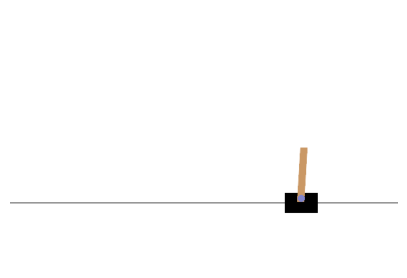

In [18]:
#Without online adpation
noAdapt_reward = []
actor.load_state_dict(actor_state_dict)
critic.load_state_dict(critic_state_dict)
critic_target.load_state_dict(critic_state_dict)

optimizer_actor = torch.optim.Adam(actor.parameters(), lr=0.)
optimizer_critic = torch.optim.Adam(critic.parameters(), lr=0.,)

for i in range(num_trials):
    total_reward, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     optimizer_actor, optimizer_critic,
                                                     adapt=False, visualize=visualize,)
    noAdapt_reward.append(total_reward)
    if total_reward <0:
        imageio.mimsave("../Figures/cartpole_noAdapt%.1f.gif"%total_reward, frames, fps=30)

noAdapt_reward = np.array(noAdapt_reward)
print("Average Reward without adaptation: ", noAdapt_reward.mean())

In [90]:
#With online adpation
Adapt_reward = []
for i in range(num_trials):
    actor.load_state_dict(actor_state_dict)
    critic.load_state_dict(critic_state_dict)
    critic_target.load_state_dict(critic_state_dict)
    
    optimizer_actor = torch.optim.Adam(
        actor.parameters(),
        lr=2e-4,
        betas=(0.92, 0.999)
    )
    
    optimizer_critic = torch.optim.Adam(
        critic.parameters(),
        lr=1e-3,
        betas=(0.92, 0.999)
    )
    
    total_reward, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     optimizer_actor, optimizer_critic,
                                                     adapt=True, visualize=visualize,)
    Adapt_reward.append(total_reward)
    if total_reward >700:
        imageio.mimsave("../Figures/cartpole_Adapt%.1f.gif"%total_reward, frames, fps=30)
Adapt_reward = np.array(Adapt_reward)
print("Average Reward with adaptation: ", Adapt_reward.mean())

Average Reward with adaptation:  93.25311


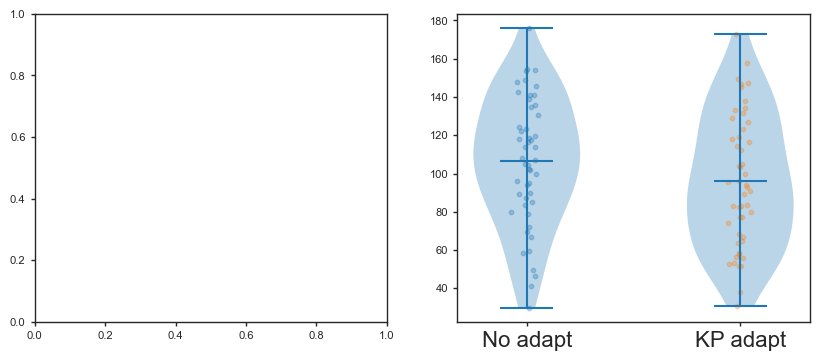

In [80]:
#TODO plot the bar with many runs
fig, axs = plt.subplots(1, 2, figsize = (10, 4))

data = [noAdapt_reward, Adapt_reward]
axs[1].violinplot(data, positions=[0,1], showmeans=True)
axs[1].set_xticks([0,1], ['No adapt', 'KP adapt'], fontsize=16)

for i, d in enumerate(data):
    x = np.random.normal(i, 0.03, size=len(d))  # small horizontal jitter
    axs[1].scatter(x, d, alpha=0.3, s=10)

#plt.savefig('./fig/LinRegCf%s.png'%activation)
plt.show()

In [ ]:
#TODO multi-episode learn, faster than BPTT?